# Do last night's winners keep winning at night — and give it back by day? 🌙🔀☀️
### The overnight/intraday "tug of war" — a real cross-sectional pattern that nets to almost nothing

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a strange, specific claim from a 2019 finance paper (Lou, Polk & Skouras): take the stocks that did *best overnight* lately — the ones that keep jumping between yesterday's close and this morning's open — and they'll **keep** earning overnight, while quietly **giving it back during the trading day**. The stocks that did *worst* overnight do the mirror image. The two forces pull against each other — a tug of war between night and day.

Most desk folklore like this evaporates when you count it. This one doesn't — the pattern is genuinely there. What evaporates is the *money*.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 50 liquid US large-caps, daily OHLC (total-return), 2010→2026. The universe is *today's* mega-caps (a survivor set), so the sizes below are an upper bound. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from overnight_intraday_tug import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_panel()
    ON, IDC = st.leg_panels(PANEL)
    SP = st.tug_spreads(ON, IDC, window=21, frac=0.3)
else:
    PANEL = ON = IDC = SP = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)),
      "| spread days:", (0 if SP is None else len(SP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'n_names': 50, 'n_days': 4125, 'on_bps': 3.71, 'id_bps': -2.39, 'cc_bps': 1.32, 'tug_bps': 6.1, 'on_t_nw': 4.62, 'id_t_nw': -2.36, 'cc_t_nw': 1.06, 'tug_t_nw': 4.59, 'on_t_1s': 4.4, 'id_t_1s': -2.27, 'on_sharpe': 1.09, 'on_top_bps': 6.76, 'on_bot_bps': 3.05, 'id_top_bps': 1.65, 'id_bot_bps': 4.04, 'on_welch': 2.12, 'id_welch': -1.16, 'placebo_obs': 3.71, 'placebo_mean': 0.001, 'placebo_sd': 0.597, 'placebo_p': 0.0, 'placebo_draws': 1000, 'era_split': '2018-01-01', 'era_early_on_bps': 2.99, 'era_early_on_t': 4.32, 'era_early_id_bps': -3.9, 'era_early_id_t': -3.21, 'era_early_n': 1991, 'era_late_on_bps': 4.38, 'era_late_on_t': 3.11, 'era_late_id_bps': -0.97, 'era_late_id_t': -0.62, 'era_late_n': 2134, 'timer_1_gross': 3.71, 'timer_1_cost': 4.14, 'timer_1_net': -0.43, 'timer_1_t': -0.51, 'timer_1_sharpe': -0.13, 'timer_1_ann': -1.1, 'timer_5_gross': 3.71, 'timer_5_cost': 20.14, 'timer_5_net': -16.43, 'timer_5_t': -19.49, 'timer_5_sharpe': -4.82, 'timer_5_ann': -41.4, 'syn_null_on_mean': -0.19, 'syn_null_on_sd': 1.03, 'syn_null_fire': 0, 'syn_planted_on_t': 10.51, 'syn_planted_id_t': -11.15, 'fp_oc': 'd3f2054309d3', 'fp_close': '357fd262912f'}


real cache present: True | names: 50 | spread days: 4125


## The answer first

| Question | Answer |
|---|---|
| Do past-overnight winners keep winning **overnight**? | **Yes.** The high-minus-low spread earns **+3.71 bps every night** — a persistence so steady its gross Sharpe is ~1.1, and a random reshuffle beats it about **0 times in 1,000**. |
| Do they **reverse** during the day? | **Yes.** The very same names lose **-2.39 bps intraday** — the mirror image. Night and day pull opposite ways. |
| So is it free money? | **No — the legs almost cancel.** Add night + day and the whole thing nets to **+1.32 bps** close-to-close, statistically indistinguishable from zero. It's a *redistribution* within the day, not a premium. |
| Can you harvest just the good (night) leg? | **No.** Grabbing the overnight leg means trading the whole book in at the close and out at the open — four spread-crossings a day. Even at a **1 bp** cost that friction (**4.1 bps/day**) is *bigger than the entire +3.71 bps edge*. |

> The pattern is real and beautiful. The paycheck is a mirage.

## 1 · The claim

> *"A stock's return has two halves — the **overnight** move (yesterday's close to this morning's open) and the **intraday** move (open to close). These two halves are driven by different crowds, and they pull in opposite directions: whatever pushes a stock up overnight tends to persist overnight and unwind intraday."*

This is the Lou-Polk-Skouras *tug of war*. The intuition: one crowd (retail, news-chasers) piles in around the open and overnight; another (institutions, market-makers) leans against them during the day. Sort stocks on how they've been doing overnight lately, and you should see the winners keep their overnight edge and lose it back by the close.

## 2 · So what?

If real, it rewrites how you read a backtest. A strategy that looks flat on close-to-close returns might secretly be a *strong* overnight bet fighting a *strong* intraday bet — two real edges hidden inside a boring-looking line. And it means the clock you trade on matters as much as the stock you pick: the same signal can be money at night and poison by day.

## 3 · How would we even know?

- **The sort.** Every day, rank our 50 stocks by their trailing overnight return (using only info known by yesterday's close — no peeking). Buy the top third, short the bottom third.
- **The two legs.** Measure that long-short book's *overnight* return and its *intraday* return, separately, every day.
- **The luck check.** Randomly scramble which stock's future is attached to which ranked stock, 1,000 times — how often does a random shuffle match the real overnight spread?
- **The trade check.** Try to actually capture the good (overnight) leg, paying realistic costs for the in-and-out trading it needs.

## 4 · The teardown — let's actually look

**First, the two legs of the sorted spread.**

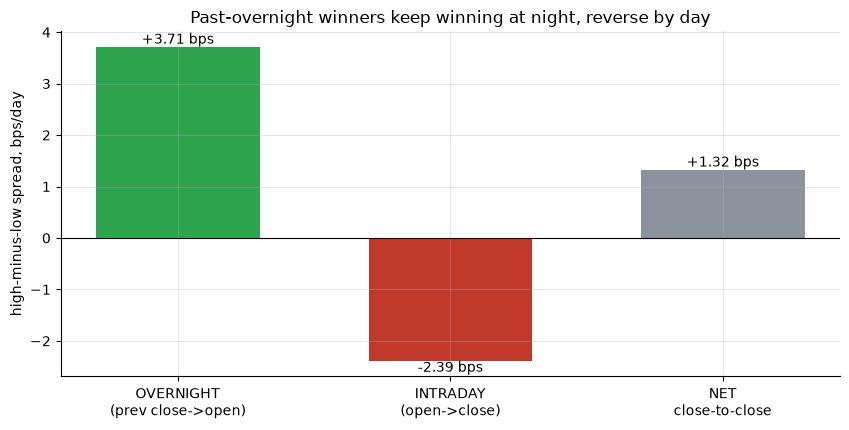

overnight +3.71 bps | intraday -2.39 bps | net +1.32 bps


In [2]:
if HAVE_REAL:
    h = st.tug_stats(SP)
    on, idn, cc = h['on_mean_bps'], h['id_mean_bps'], h['cc_mean_bps']
else:
    on, idn, cc = R['on_bps'], R['id_bps'], R['cc_bps']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['OVERNIGHT\n(prev close->open)','INTRADAY\n(open->close)','NET\nclose-to-close'],
       [on, idn, cc], color=[GREEN, RED, GREY], width=.6)
for i,v in enumerate([on, idn, cc]): ax.annotate(f'{v:+.2f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('high-minus-low spread, bps/day')
ax.set_title('Past-overnight winners keep winning at night, reverse by day')
plt.tight_layout(); plt.show()
print(f'overnight {on:+.2f} bps | intraday {idn:+.2f} bps | net {cc:+.2f} bps')

There's the tug: **+3.71 bps overnight** (the winners keep winning) and **-2.39 bps intraday** (they give it back) — opposite signs, both real. And crucially the third bar: add them up and you're left with a measly **+1.32 bps** close-to-close. The two big forces very nearly cancel. The exciting part isn't a profit — it's *where inside the day* the return lives.

**Is the overnight persistence real, or a lucky alignment of the sort?** Scramble it 1,000 ways:

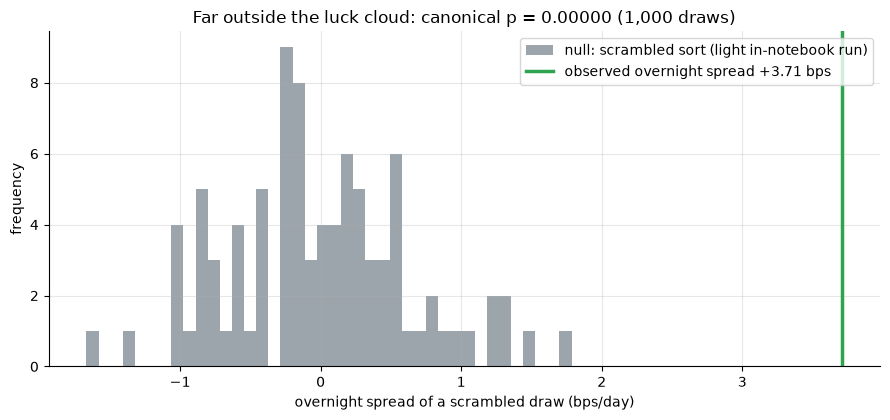

canonical placebo (results.md): mean +0.001 bps, sd 0.597, p = 0.00000


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(ON, IDC, n_seeds=6, n_draws_per_seed=15)
    obs, draws = pl['obs_bps'], pl['draws_bps']
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(788)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 500)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='null: scrambled sort (light in-notebook run)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed overnight spread {obs:+.2f} bps')
ax.set_xlabel('overnight spread of a scrambled draw (bps/day)')
ax.set_ylabel('frequency')
ax.set_title(f"Far outside the luck cloud: canonical p = {R['placebo_p']:.5f} (1,000 draws)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.3f} bps, "
      f"sd {R['placebo_sd']:.3f}, p = {R['placebo_p']:.5f}")

The real overnight spread sits **way** outside the cloud of random shuffles — about 6 standard deviations out, **p = 0.00000**. This isn't the sort getting lucky.

**Finally, the trade.** The overnight leg is the good one — can you just buy that?

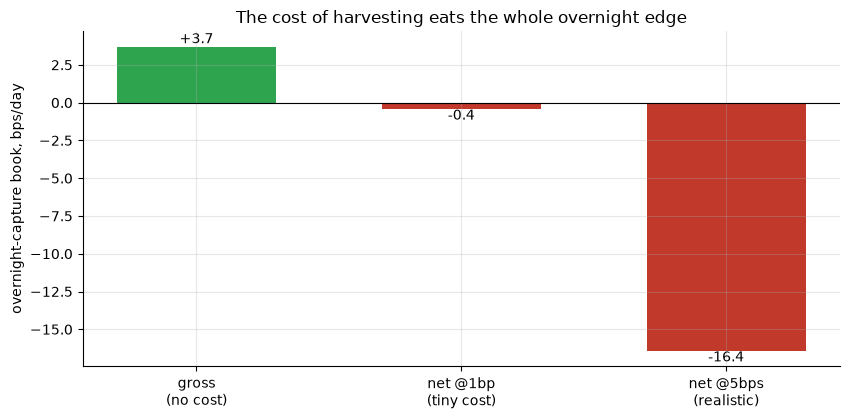

gross +3.71 -> net @1bp -0.43 -> net @5bps -16.43 bps/day


In [4]:
if HAVE_REAL:
    tm1 = st.timer_stats(SP, cost_bps=1.0)
    tm5 = st.timer_stats(SP, cost_bps=5.0)
    g, n1, n5 = tm1['gross_bps'], tm1['net_bps'], tm5['net_bps']
else:
    g, n1, n5 = R['timer_1_gross'], R['timer_1_net'], R['timer_5_net']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['gross\n(no cost)','net @1bp\n(tiny cost)','net @5bps\n(realistic)'], [g, n1, n5],
       color=[GREEN, RED, RED], width=.6)
for i,v in enumerate([g, n1, n5]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('overnight-capture book, bps/day')
ax.set_title('The cost of harvesting eats the whole overnight edge')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} -> net @1bp {n1:+.2f} -> net @5bps {n5:+.2f} bps/day')

Grabbing the overnight leg means being *in* the book at every close and *out* at every open — you cross the bid-ask four times a day on a double-sized (long+short) book. That friction is **4.1 bps/day at just 1 bp** a crossing — already more than the entire **+3.71 bps** you were trying to earn. Net: **-0.43 bps/day** (a loss). At a realistic 5 bps it's **-41%/yr**. The edge is real; harvesting it costs more than it's worth.

## 5 · The verdict

- **Signal — Real.** The overnight leg persists (**+3.71 bps/day**, a 6σ placebo result) and the intraday leg reverses (**-2.39 bps/day**) — a genuine, robust tug of war, holding across both halves of the sample.
- **Tradability — Mirage.** The two legs nearly cancel close-to-close (**+1.32 bps**, not significant), and harvesting the one good leg costs more than it earns at any realistic price. Real physics, no paycheck.
- *Survivorship note:* these are today's mega-caps, so the sizes are an upper bound — which only makes the mirage verdict safer.

## 6 · Going further 🚪

- **Why does it happen?** The leading story is *clientele*: different investors trade at different times of day, and their opposing pressures leave a persistent overnight print that the daytime crowd fades. A follow-up could tie the size of the tug to retail order-flow or overnight news.
- **Where it might matter** isn't as a standalone trade but as a *lens*: if you already hold a book overnight for other reasons, knowing the overnight and intraday legs of your signal point opposite ways tells you which clock is actually paying you.
- **Sibling studies:** [01-overnight-anomaly](../../01-overnight-anomaly/) (the whole *market's* night-vs-day split — not a cross-sectional sort), [640-gold-overnight](../../640-gold-overnight/) (the same split on *one asset*), and [116-power-hour](../../116-power-hour/) (an intraday-*clock* effect) — see [docs/references.md](docs/references.md) for the exact dedup.

*Think you can harvest the overnight leg cheaper than four crossings a day? Show a net, certifiable edge after realistic frictions on the size you'd actually run — then we'll talk.*